In [1]:
# Python & sklearn version check
import sys
import sklearn

assert sys.version_info >= (3, 5)
assert sklearn.__version__ >= "0.20"

# Common imports
import numpy as np
import matplotlib.pyplot as plt

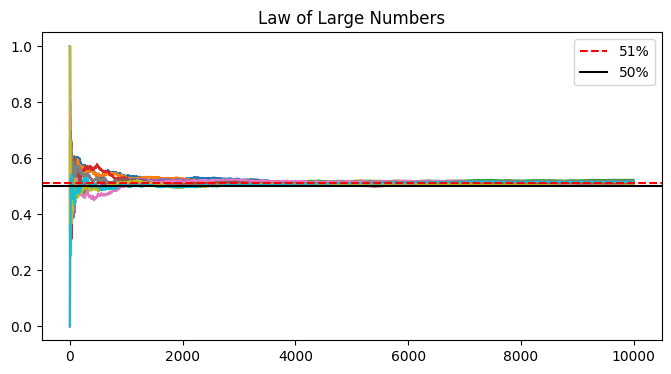

In [2]:
heads_proba = 0.51

coin_tosses = (np.random.rand(10000, 10) < heads_proba).astype(int)

cumulative_heads_ratio = np.cumsum(coin_tosses, axis=0) / np.arange(1, 10001).reshape(-1, 1)

# Plot
plt.figure(figsize=(8,4))
plt.plot(cumulative_heads_ratio)
plt.axhline(y=0.51, color='r', linestyle='--', label="51%")
plt.axhline(y=0.5, color='k', label="50%")
plt.legend()
plt.title("Law of Large Numbers")
plt.show()

In [3]:
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split

X, y = make_moons(n_samples=500, noise=0.30, random_state=42)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [4]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

log_clf = LogisticRegression()
rnd_clf = RandomForestClassifier()
svm_clf = SVC(probability=True)


In [5]:
from sklearn.ensemble import VotingClassifier

voting_clf = VotingClassifier(
    estimators=[
        ('lr', log_clf),
        ('rf', rnd_clf),
        ('svc', svm_clf)
    ],
    voting='soft'
)

voting_clf.fit(X_train, y_train)


,estimators,"[('lr', ...), ('rf', ...), ...]"
,voting,'soft'
,weights,None
,n_jobs,None
,flatten_transform,True
,verbose,False
,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True


In [6]:
from sklearn.metrics import accuracy_score

models = [log_clf, rnd_clf, svm_clf, voting_clf]

for model in models:
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    print(model.__class__.__name__, accuracy_score(y_test, y_pred))

    

LogisticRegression 0.85
RandomForestClassifier 0.88
SVC 0.87
VotingClassifier 0.88


In [7]:
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier

bag_clf = BaggingClassifier(
    DecisionTreeClassifier(),
    n_estimators=500,
    max_samples=100,
    bootstrap=True,
    random_state=42
)

bag_clf.fit(X_train, y_train)

y_pred = bag_clf.predict(X_test)

print("Bagging Accuracy:", accuracy_score(y_test, y_pred))

Bagging Accuracy: 0.9


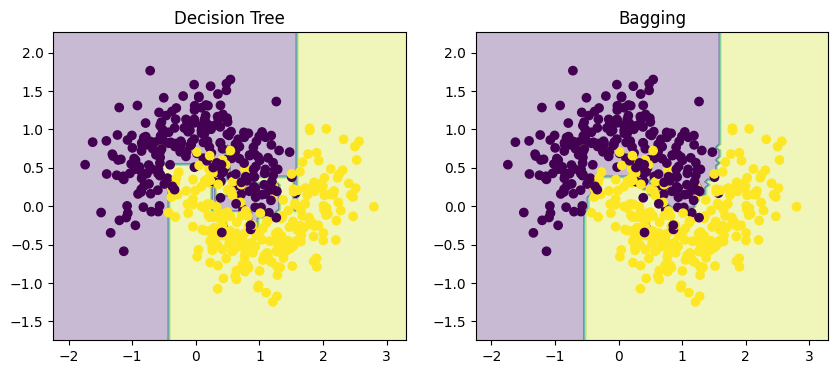

In [8]:
from matplotlib.colors import ListedColormap

def plot_decision_boundary(clf, X, y):
    x_min, x_max = X[:,0].min()-0.5, X[:,0].max()+0.5
    y_min, y_max = X[:,1].min()-0.5, X[:,1].max()+0.5

    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100),
                         np.linspace(y_min, y_max, 100))

    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.contourf(xx, yy, Z, alpha=0.3)
    plt.scatter(X[:,0], X[:,1], c=y)

# Plot
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
tree = DecisionTreeClassifier().fit(X_train, y_train)
plot_decision_boundary(tree, X, y)
plt.title("Decision Tree")

plt.subplot(1,2,2)
plot_decision_boundary(bag_clf, X, y)
plt.title("Bagging")

plt.show()

In [9]:
from sklearn.ensemble import RandomForestClassifier

rf_clf = RandomForestClassifier(n_estimators=500, max_leaf_nodes=16)

rf_clf.fit(X_train, y_train)

y_pred = rf_clf.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred))

Random Forest Accuracy: 0.89


In [10]:
bag_clf = BaggingClassifier(
    DecisionTreeClassifier(),
    n_estimators=500,
    bootstrap=True,
    oob_score=True
)

bag_clf.fit(X_train, y_train)

print("OOB Score:", bag_clf.oob_score_)

OOB Score: 0.9025
